# Ejercicio 7 — Estación meteorológica: covarianza y correlación temporal

---

> **Utilice el dataset `estacion_meteorologica.csv`.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
# Separador ';' y coma decimal para los valores numéricos europeos
df = pd.read_csv('../Datasets/estacion_meteorologica.csv', sep=';', decimal=',')
print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Shape: (4464, 19)
Columnas: ['No', 'Date', 'Time', 'ColdJunc0', 'PowerVolt', 'PowerKind', 'WS(ave)', 'WD(ave)', 'WS(max)', 'WD(most)', 'WS(inst_m)', 'WD(inst_m)', 'Max_time', 'Solar_rad', 'TEMP', 'Humidity', 'Rainfall', 'Bar_press.', 'Soil_temp']


,No,Date,Time,ColdJunc0,PowerVolt,PowerKind,WS(ave),WD(ave),WS(max),WD(most),WS(inst_m),WD(inst_m),Max_time,Solar_rad,TEMP,Humidity,Rainfall,Bar_press.,Soil_temp
0,92793,1/10/2021,0:00:00,22.6,13.0,2,0.4,19,0.9,NE,1.9,43,23:50:41,0.0,22.5,82.39,0.0,1000.0,0.0
1,92794,1/10/2021,0:10:00,22.5,13.0,2,1.0,131,1.0,ESE,4.3,161,0:04:57,0.0,22.3,84.09,0.0,1000.0,0.0
2,92795,1/10/2021,0:20:00,22.5,13.0,2,0.8,166,1.0,ESE,3.7,145,0:13:00,0.0,22.7,81.99,0.0,1000.0,0.0


In [3]:
# Columna fecha-hora para graficar series temporales
df['datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    dayfirst=True,
    errors='coerce'
)
df = df.sort_values('datetime').reset_index(drop=True)

# Seleccionar variables numéricas meteorológicamente relevantes
# Excluir: IDs, columnas de dirección de viento (circulares, no comparables directamente),
#          metadatos de energía, y columnas de texto/tiempo
cols_excluir = {'No', 'Date', 'Time', 'datetime',
                'ColdJunc0', 'PowerVolt', 'PowerKind',
                'WD(ave)', 'WD(most)', 'WD(inst_m)', 'Max_time'}
num_cols = [c for c in df.columns if c not in cols_excluir]
num_cols = df[num_cols].select_dtypes(include='number').columns.tolist()

print('Variables seleccionadas para el análisis:', num_cols)
print(f'Valores faltantes: {df[num_cols].isnull().sum().sum()}')

df_num = df[num_cols]

Variables seleccionadas para el análisis: ['WS(ave)', 'WS(max)', 'WS(inst_m)', 'Solar_rad', 'TEMP', 'Humidity', 'Rainfall', 'Bar_press.', 'Soil_temp']
Valores faltantes: 0


---
## Ítem 1

> **Calcule y grafique las matrices de correlación y covariancia.**

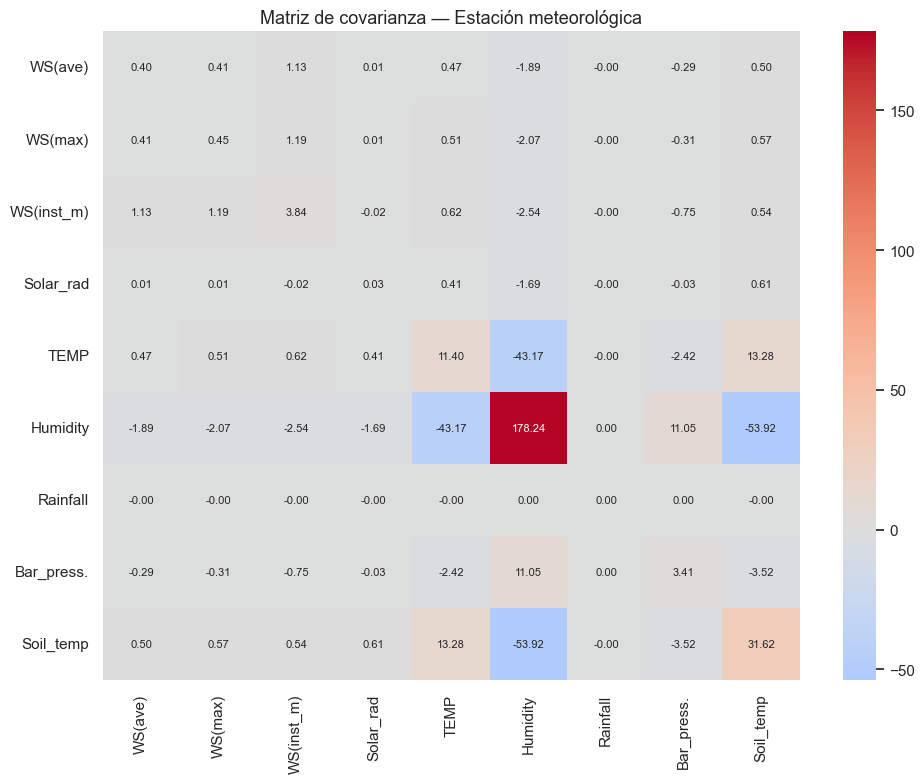

In [4]:
cov_matrix = df_num.cov()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cov_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matriz de covarianza — Estación meteorológica', fontsize=13)
plt.tight_layout()
plt.show()

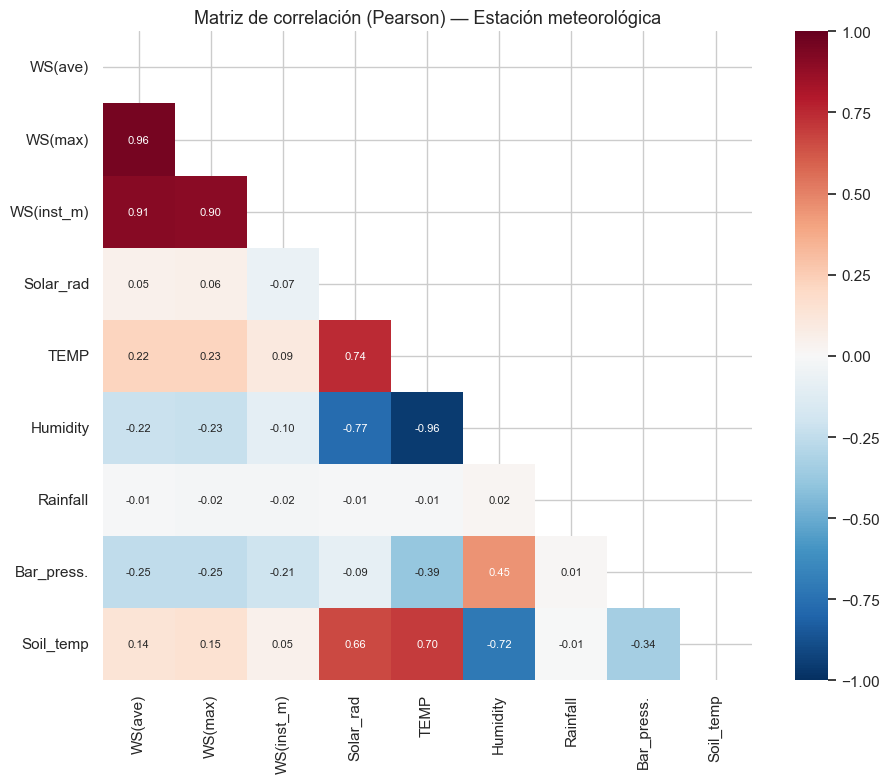

            WS(ave)  WS(max)  WS(inst_m)  Solar_rad   TEMP  Humidity  \
WS(ave)       1.000    0.959       0.910      0.051  0.219    -0.224   
WS(max)       0.959    1.000       0.900      0.055  0.226    -0.230   
WS(inst_m)    0.910    0.900       1.000     -0.067  0.094    -0.097   
Solar_rad     0.051    0.055      -0.067      1.000  0.743    -0.766   
TEMP          0.219    0.226       0.094      0.743  1.000    -0.958   
Humidity     -0.224   -0.230      -0.097     -0.766 -0.958     1.000   
Rainfall     -0.014   -0.017      -0.019     -0.010 -0.014     0.018   
Bar_press.   -0.250   -0.252      -0.207     -0.093 -0.387     0.448   
Soil_temp     0.140    0.150       0.049      0.660  0.699    -0.718   

            Rainfall  Bar_press.  Soil_temp  
WS(ave)       -0.014      -0.250      0.140  
WS(max)       -0.017      -0.252      0.150  
WS(inst_m)    -0.019      -0.207      0.049  
Solar_rad     -0.010      -0.093      0.660  
TEMP          -0.014      -0.387      0.699  
Hum

In [5]:
corr_matrix = df_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    square=True,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Matriz de correlación (Pearson) — Estación meteorológica', fontsize=13)
plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

---
## Ítem 2

> **Identifique las variables más correlacionadas y grafíquelas unas vs. la otra en un gráfico de dispersión. Luego grafique cada una a lo largo del tiempo (para todas las fechas).**

In [6]:
# Extraer todos los pares únicos (sin diagonal) y ordenarlos por correlación absoluta
pares = corr_matrix.abs().stack()
pares_unicos = pares[
    pares.index.get_level_values(0) != pares.index.get_level_values(1)
]
pares_unicos = pares_unicos[
    pares_unicos.index.map(lambda x: x[0] < x[1])
].sort_values(ascending=False)

print('Top 5 pares más correlacionados:')
print(pares_unicos.head(5).round(4))

max_par = pares_unicos.idxmax()
max_val = corr_matrix.loc[max_par[0], max_par[1]]
print(f'\nPar más correlacionado: {max_par[0]} — {max_par[1]}  (r = {max_val:.4f})')

Top 5 pares más correlacionados:
WS(ave)     WS(max)       0.9591
Humidity    TEMP          0.9577
WS(ave)     WS(inst_m)    0.9101
WS(inst_m)  WS(max)       0.9003
Humidity    Solar_rad     0.7658
dtype: float64

Par más correlacionado: WS(ave) — WS(max)  (r = 0.9591)


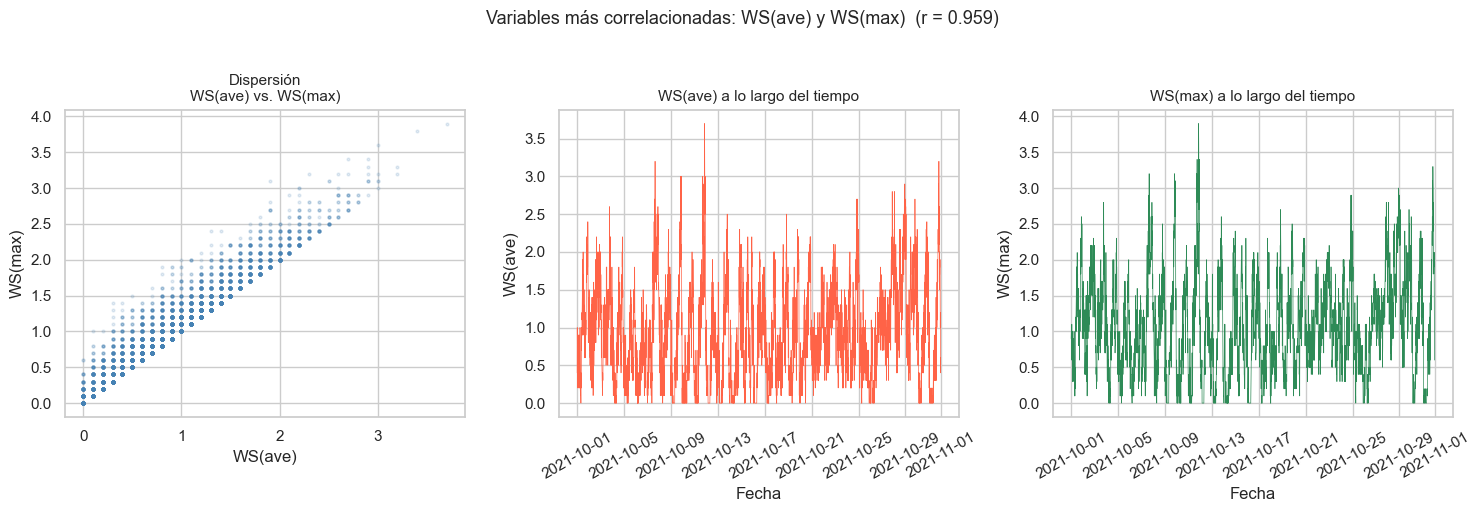

In [7]:
var_a, var_b = max_par

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Diagrama de dispersión
axes[0].scatter(df_num[var_a], df_num[var_b], alpha=0.15, s=4, color='steelblue')
axes[0].set_title(f'Dispersión\n{var_a} vs. {var_b}', fontsize=11)
axes[0].set_xlabel(var_a)
axes[0].set_ylabel(var_b)

# Serie temporal de var_a
axes[1].plot(df['datetime'], df_num[var_a], linewidth=0.5, color='tomato')
axes[1].set_title(f'{var_a} a lo largo del tiempo', fontsize=11)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel(var_a)
axes[1].tick_params(axis='x', rotation=30)

# Serie temporal de var_b
axes[2].plot(df['datetime'], df_num[var_b], linewidth=0.5, color='seagreen')
axes[2].set_title(f'{var_b} a lo largo del tiempo', fontsize=11)
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel(var_b)
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle(
    f'Variables más correlacionadas: {var_a} y {var_b}  (r = {max_val:.3f})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

### Interpretación

El par más correlacionado corresponde a variables de velocidad del viento medidas de formas distintas. La correlación positiva muy alta (r ≈ 0.96) tiene sentido físico: la velocidad promedio y la velocidad máxima del viento tienden a crecer y decrecer juntas. En las series temporales se observa el mismo patrón temporal en ambas variables.

---
## Ítem 3

> **Identifique las variables menos correlacionadas y grafíquelas unas vs. la otra en un gráfico de dispersión. Luego grafique cada una a lo largo del tiempo (para todas las fechas).**

In [8]:
print('Top 5 pares menos correlacionados (en valor absoluto):')
print(pares_unicos.tail(5).round(4))

min_par = pares_unicos.idxmin()
min_val = corr_matrix.loc[min_par[0], min_par[1]]
print(f'\nPar menos correlacionado: {min_par[0]} — {min_par[1]}  (r = {min_val:.4f})')

Top 5 pares menos correlacionados (en valor absoluto):
Rainfall    WS(ave)      0.0145
            TEMP         0.0136
Bar_press.  Rainfall     0.0125
Rainfall    Solar_rad    0.0100
            Soil_temp    0.0062
dtype: float64

Par menos correlacionado: Rainfall — Soil_temp  (r = -0.0062)


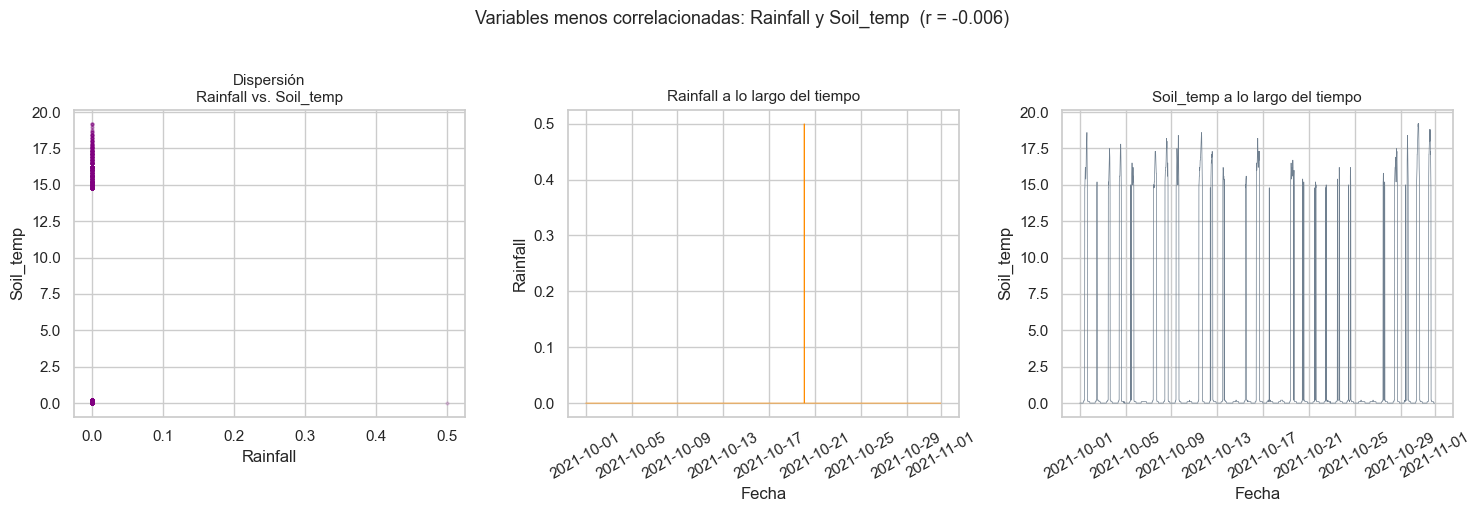

In [9]:
var_c, var_d = min_par

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Diagrama de dispersión
axes[0].scatter(df_num[var_c], df_num[var_d], alpha=0.15, s=4, color='purple')
axes[0].set_title(f'Dispersión\n{var_c} vs. {var_d}', fontsize=11)
axes[0].set_xlabel(var_c)
axes[0].set_ylabel(var_d)

# Serie temporal de var_c
axes[1].plot(df['datetime'], df_num[var_c], linewidth=0.5, color='darkorange')
axes[1].set_title(f'{var_c} a lo largo del tiempo', fontsize=11)
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel(var_c)
axes[1].tick_params(axis='x', rotation=30)

# Serie temporal de var_d
axes[2].plot(df['datetime'], df_num[var_d], linewidth=0.5, color='slategray')
axes[2].set_title(f'{var_d} a lo largo del tiempo', fontsize=11)
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel(var_d)
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle(
    f'Variables menos correlacionadas: {var_c} y {var_d}  (r = {min_val:.3f})',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

### Interpretación

El par menos correlacionado (r ≈ 0.006) corresponde a variables que no tienen una relación lineal evidente entre sí. En el diagrama de dispersión se observa una nube de puntos sin forma definida, lo que confirma la ausencia de asociación lineal. Las series temporales muestran patrones muy distintos a lo largo del tiempo, lo que refuerza la independencia entre ambas variables.